In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pandas_profiling as pp
import keras as k

<ipython-input-3-69d5237064c4>:4: DeprecationWarning: `import pandas_profiling` is going to be deprecated by April 1st. Please use `import ydata_profiling` instead.
  import pandas_profiling as pp


In [2]:
!pip install ydata-profiling


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 390.9/390.9 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.5/296.5 kB 21.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 687.8/687.8 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.8/104.8 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 61.1 MB/s eta 0:00:00
  Created wheel for htmlmin: filename=htmlmin-0.1.12-py3-none-any.whl size=27081 sha256=9270541aef7928c26e35388d5222399867e08c87a938d8c74c31ba6f19bd9d5b
  Stored in directory: /root/.cache/pip/wheels/8d/55/1a/19cd535375ed1ede0c996405ebffe34b196d78e2d9545723a2
Successfully built htmlmin


In [4]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)


In [5]:
df_users = pd.read_csv("/content/fusers.csv")
df_fusers = pd.read_csv("/content/users.csv")

In [6]:
print(df_fusers.shape)
print(df_users.shape)

(3474, 42)
(3351, 38)


In [7]:
df_fusers.isnull().sum()# represents all the null values from each coulumn in fusers

,0
id,0
name,1
screen_name,0
statuses_count,0
followers_count,0
friends_count,0
favourites_count,0
listed_count,0
url,2208
lang,0


In [8]:
#for df_fusers
isFake = np.ones(3351)
#for df_fusers
isFake = np.ones(3351)

#for df_users
isNotFake = np.zeros(3474)

In [9]:
# Assign 1 (Fake) to df_fusers
isFake = np.ones(len(df_fusers))  # Ensure length matches
df_fusers["isFake"] = isFake

# Assign 0 (Not Fake) to df_users
isNotFake = np.zeros(len(df_users))  # Ensure length matches
df_users["isFake"] = isNotFake


In [10]:
df_allUsers = pd.concat([df_fusers, df_users], ignore_index=True)
df_allUsers.columns = df_allUsers.columns.str.strip()

In [11]:
#to shuffle the whole data
df_allUsers = df_allUsers.sample(frac=1).reset_index(drop=True)

In [12]:
df_allUsers.describe()

,id,statuses_count,followers_count,friends_count,favourites_count,listed_count,default_profile,default_profile_image,geo_enabled,profile_use_background_image,...,is_translator,follow_request_sent,protected,verified,notifications,contributors_enabled,following,test_set_1,test_set_2,isFake
count,6.825000e+03,6825.000000,6825.000000,6825.000000,6825.000000,6825.000000,4066.0,19.0,2294.0,6426.0,...,1.0,0.0,78.0,11.0,0.0,0.0,0.0,3474.000000,3474.000000,6825.000000
mean,8.499737e+08,8667.221685,717.874432,504.022564,2378.999121,9.959853,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,0.287853,0.141048,0.509011
std,7.662248e+08,23473.945131,12301.657025,1159.286294,8548.235726,112.952257,0.0,0.0,0.0,0.0,...,NaN,NaN,0.0,0.0,NaN,NaN,NaN,0.452827,0.348121,0.499955
min,6.780330e+05,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,0.000000,0.000000,0.000000
25%,2.597067e+08,23.000000,12.000000,206.000000,0.000000,0.000000,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,0.000000,0.000000,0.000000
50%,6.168972e+08,190.000000,33.000000,312.000000,10.000000,0.000000,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,0.000000,0.000000,1.000000
75%,1.174963e+09,6900.000000,349.000000,555.000000,1360.000000,2.000000,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,1.000000,0.000000,1.000000
max,3.164942e+09,399555.000000,986837.000000,46310.000000,313954.000000,6166.000000,1.0,1.0,1.0,1.0,...,1.0,NaN,1.0,1.0,NaN,NaN,NaN,1.000000,1.000000,1.000000


In [13]:
print(df_allUsers)


              id             name      screen_name  statuses_count  \
0      616219802   Candace Gordon  candacegordonxd              54   
1     1664307984    laurel daniel    _laureldaniel            1770   
2      423666184     dawn windsor       dawn_winds             500   
3     1175039382     Pansy Hughey   HugheyzssPansy              25   
4      616220111    Cherie Dawson       dawsoncfua              48   
...          ...              ...              ...             ...   
6820   616285659       Chris Hahn          hahnctz               0   
6821  2500522076         スーパーヤサイ人         rsl_rgls           45091   
6822  1318895588             Evan         Evan_scb           20276   
6823    39030312  Phoebe Shaine ♔    shaineephoebe           13186   
6824    83293188     Marilyn Chua          MChuaWY            1017   

      followers_count  friends_count  favourites_count  listed_count  \
0                  24            672                 0             0   
1              

In [14]:
Y = df_allUsers.isFake

In [15]:
Y.head()

,isFake
0,0.0
1,1.0
2,1.0
3,0.0
4,0.0


In [16]:
df_allUsers.columns

Index(['id', 'name', 'screen_name', 'statuses_count', 'followers_count',
       'friends_count', 'favourites_count', 'listed_count', 'url', 'lang',
       'time_zone', 'location', 'default_profile', 'default_profile_image',
       'geo_enabled', 'profile_image_url', 'profile_banner_url',
       'profile_use_background_image', 'profile_background_image_url_https',
       'profile_text_color', 'profile_image_url_https',
       'profile_sidebar_border_color', 'profile_background_tile',
       'profile_sidebar_fill_color', 'profile_background_image_url',
       'profile_background_color', 'profile_link_color', 'utc_offset',
       'is_translator', 'follow_request_sent', 'protected', 'verified',
       'notifications', 'description', 'contributors_enabled', 'following',
       'created_at', 'timestamp', 'crawled_at', 'updated', 'test_set_1',
       'test_set_2', 'isFake'],
      dtype='object')

In [17]:
df1=df_allUsers[['id','favourites_count','followers_count','statuses_count','friends_count','default_profile','default_profile_image','profile_use_background_image','utc_offset','listed_count','geo_enabled','lang','isFake']]

In [18]:
df1.head()

,id,favourites_count,followers_count,statuses_count,friends_count,default_profile,default_profile_image,profile_use_background_image,utc_offset,listed_count,geo_enabled,lang,isFake
0,616219802,0,24,54,672,1.0,NaN,1.0,NaN,0,NaN,en,0.0
1,1664307984,1224,179,1770,132,1.0,NaN,1.0,NaN,0,NaN,en,1.0
2,423666184,868,28,500,196,1.0,NaN,1.0,3600.0,1,NaN,en,1.0
3,1175039382,0,11,25,201,1.0,NaN,1.0,NaN,0,NaN,en,0.0
4,616220111,0,28,48,582,1.0,NaN,1.0,NaN,0,NaN,en,0.0


In [19]:
lang_list = list(enumerate(np.unique(df1["lang"])))
lang_dict = {name : i for i, name in lang_list}
print(lang_dict)

{'Select Language...': 0, 'ar': 1, 'da': 2, 'de': 3, 'el': 4, 'en': 5, 'en-AU': 6, 'en-GB': 7, 'en-gb': 8, 'es': 9, 'fil': 10, 'fr': 11, 'id': 12, 'it': 13, 'ja': 14, 'ko': 15, 'nl': 16, 'pl': 17, 'pt': 18, 'ru': 19, 'sv': 20, 'tr': 21, 'xx-lc': 22, 'zh-TW': 23, 'zh-cn': 24, 'zh-tw': 25}


In [20]:
z=df1.loc[:, "lang_num"] = df1["lang"].map(lambda x: lang_dict[x]).astype(int)

<ipython-input-20-1bb44228d068>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  z=df1.loc[:, "lang_num"] = df1["lang"].map(lambda x: lang_dict[x]).astype(int)


In [21]:
df1.drop(["lang"], axis=1, inplace=True)

<ipython-input-21-a0d022605937>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(["lang"], axis=1, inplace=True)


In [22]:
df1.drop(["isFake"], axis=1, inplace=True)

<ipython-input-22-d9aaa4fb4dc0>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.drop(["isFake"], axis=1, inplace=True)


In [23]:
df1.head()

,id,favourites_count,followers_count,statuses_count,friends_count,default_profile,default_profile_image,profile_use_background_image,utc_offset,listed_count,geo_enabled,lang_num
0,616219802,0,24,54,672,1.0,NaN,1.0,NaN,0,NaN,5
1,1664307984,1224,179,1770,132,1.0,NaN,1.0,NaN,0,NaN,5
2,423666184,868,28,500,196,1.0,NaN,1.0,3600.0,1,NaN,5
3,1175039382,0,11,25,201,1.0,NaN,1.0,NaN,0,NaN,5
4,616220111,0,28,48,582,1.0,NaN,1.0,NaN,0,NaN,5


In [24]:
df1.isnull().sum()

,0
id,0
favourites_count,0
followers_count,0
statuses_count,0
friends_count,0
default_profile,2759
default_profile_image,6806
profile_use_background_image,399
utc_offset,4015
listed_count,0


In [25]:
df1 = df1.replace(np.nan, 0) #To replace the missing boolean values with zeros as it means false

In [26]:
df1.isnull().sum()

,0
id,0
favourites_count,0
followers_count,0
statuses_count,0
friends_count,0
default_profile,0
default_profile_image,0
profile_use_background_image,0
utc_offset,0
listed_count,0


In [27]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(df1, Y, test_size=0.3) # 70% training and 30% test

In [28]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(4777, 12)
(2048, 12)
(4777,)
(2048,)


**XG BOOST CLASSIFIER**



In [29]:
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import ShuffleSplit

In [30]:
cv=ShuffleSplit(n_splits=10,random_state=42,test_size=0.3)

In [31]:
!pip install --upgrade scikit-learn xgboost


In [32]:
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, ShuffleSplit

cv = ShuffleSplit(n_splits=10, test_size=0.3, random_state=42)

cross_val_score(XGBClassifier(), df1, Y, scoring='accuracy', cv=cv)


array([0.99609375, 0.9921875 , 0.99072266, 0.99316406, 0.99072266,
       0.99121094, 0.99414062, 0.98974609, 0.99560547, 0.99462891])

In [33]:
classifier = XGBClassifier()
classifier.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [34]:
# make predictions for test data
y_pred = classifier.predict(X_test)
predictions = [round(value) for value in y_pred]

In [35]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
x=accuracy
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 99.37%


**ADA BOOST CLASSIFIER**

In [36]:
from sklearn.ensemble import AdaBoostClassifier
classifier = AdaBoostClassifier(n_estimators=50,learning_rate=1)
model = classifier.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [37]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
y=accuracy
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 99.02%


**DECISION TREE CLASSIFIER**

In [38]:
from sklearn.tree import DecisionTreeClassifier # Import Decision Tree Classifier

In [39]:
from sklearn.ensemble import RandomForestClassifier
cross_val_score(DecisionTreeClassifier(),df1,Y,scoring='accuracy',cv=cv)

array([0.99121094, 0.98681641, 0.98388672, 0.98974609, 0.98730469,
       0.98583984, 0.99072266, 0.98730469, 0.98828125, 0.98486328])

In [40]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

In [41]:
# Create Decision Tree classifer object
classifier = DecisionTreeClassifier()
# Train Decision Tree Classifer
classifier = classifier.fit(X_train,y_train)
#Predict the response for test dataset
y_pred = classifier.predict(X_test)

In [42]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, predictions)
z=accuracy
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 99.37%


**RANDOM FOREST CLASSIFIER**

In [43]:
from sklearn.ensemble import RandomForestClassifier
cross_val_score(RandomForestClassifier(),df1,Y,scoring='accuracy',cv=cv)

array([0.99609375, 0.9921875 , 0.99072266, 0.99414062, 0.99169922,
       0.99072266, 0.99414062, 0.99072266, 0.99414062, 0.99365234])

In [44]:
#Import Random Forest Model
from sklearn.ensemble import RandomForestClassifier
#Create a Gaussian Classifier
classifier=RandomForestClassifier(n_estimators=100)
#Train the model using the training sets y_pred=clf.predict(X_test)
classifier.fit(X_train,y_train)
y_pred=classifier.predict(X_test)

In [45]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, y_pred)
c=accuracy
print("Accuracy: %.2f%%" % (accuracy * 100.0))

Accuracy: 99.32%


In [46]:
import sklearn
from sklearn import ensemble
from sklearn import tree
from sklearn import svm

import seaborn as sns

In [48]:
from sklearn import svm, tree, ensemble
from xgboost import XGBClassifier

model = [
    ensemble.AdaBoostClassifier(),
    ensemble.RandomForestClassifier(),
    tree.DecisionTreeClassifier(),
    ensemble.ExtraTreesClassifier(),
    svm.SVC(probability=True),
    svm.LinearSVC(),
    XGBClassifier()
]


In [49]:
from sklearn.metrics import precision_score,recall_score
from sklearn import metrics
model_columns = []
model_compare = pd.DataFrame(columns = model_columns)

In [51]:
row_index = 0
for alg in model:
    predicted = alg.fit(X_train, y_train).predict(X_test)
    model_compare.loc[row_index, 'model Test Accuracy'] = round(alg.score(X_test, y_test), 4)
    model_compare.loc[row_index, 'model Precission'] = precision_score(y_test, predicted)
    model_compare.loc[row_index, 'model Recall'] = recall_score(y_test, predicted)

model_compare.sort_values(by = ['model Test Accuracy'], ascending = False, inplace = True)
model_compare

,model Test Accuracy,model Precission,model Recall
0,0.9937,0.99334,0.994286


In [52]:
import matplotlib.pyplot as plt
%matplotlib inline
# plt.figure(figsize=[10,8])

# plt.bar(model, width = 0.5, color='#0504aa',alpha=0.7)
# plt.ylim([0.85,1])
# plt.grid(axis='y', alpha=0.75)
# plt.xlabel('Value')
# plt.ylabel('Frequency')
# plt.xticks(fontsize=15)
# plt.yticks(fontsize=15)
# plt.ylabel('Frequency',fontsize=15)
# plt.title('Normal Distribution Histogram')
# plt.show()

<ipython-input-54-7aa53e058c8e>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label, y=data, palette='hot', edgecolor=sns.color_palette('dark', 7))  # Corrected


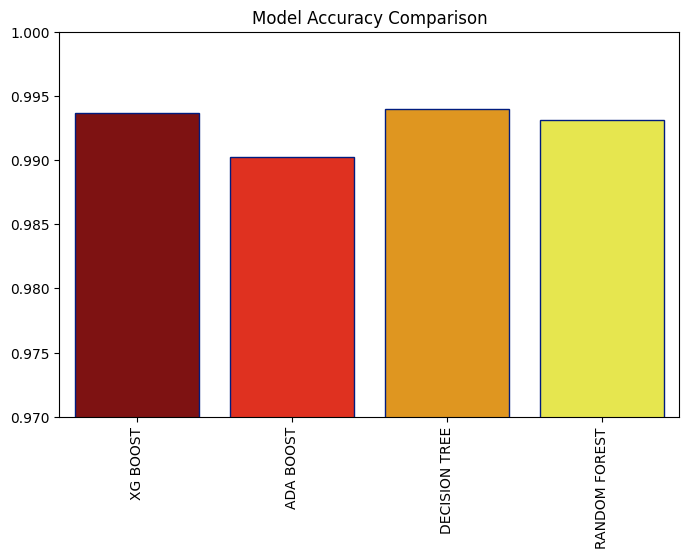

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.subplots(figsize=(8, 5))

data = []
data.append(x)
data.append(y)
data.append(0.994)
data.append(c)  # Assuming 'c' is defined

label = ['XG BOOST', 'ADA BOOST', 'DECISION TREE', 'RANDOM FOREST']

sns.barplot(x=label, y=data, palette='hot', edgecolor=sns.color_palette('dark', 7))  # Corrected

plt.xticks(rotation=90)
plt.ylim([0.97, 1])
plt.title('Model Accuracy Comparison')
plt.show()


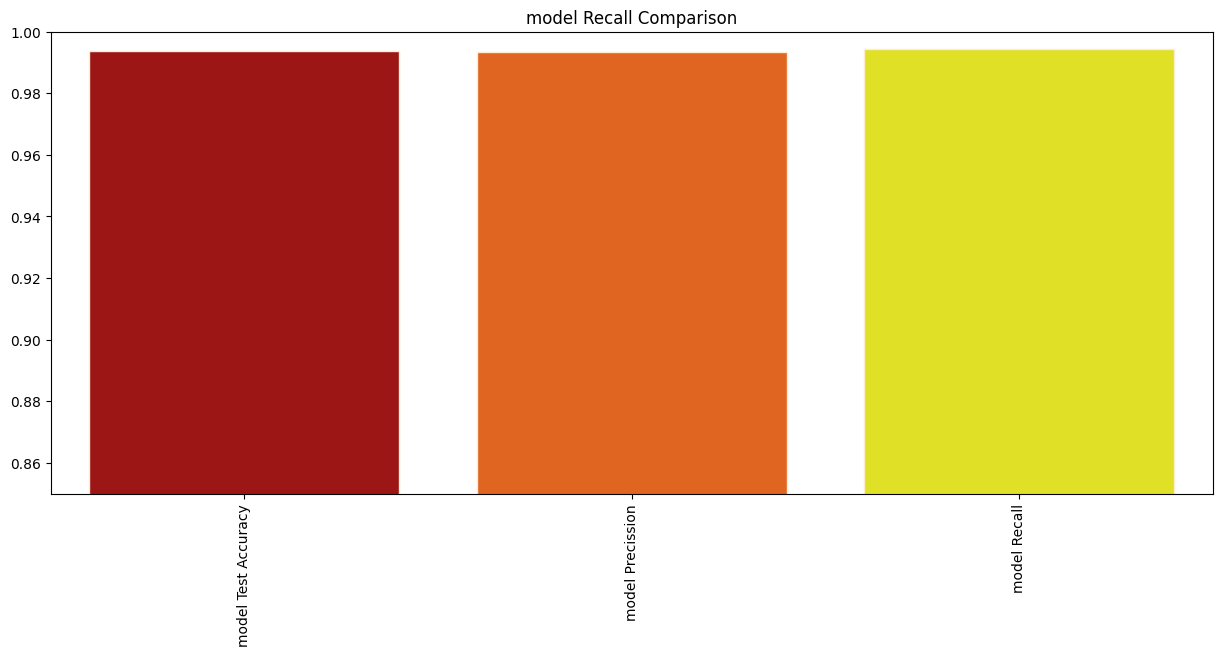

In [55]:
plt.subplots(figsize=(15,6))
sns.barplot(data=model_compare,palette='hot',edgecolor=sns.color_palette('OrRd',9))
plt.xticks(rotation=90)
plt.ylim([0.85,1])
plt.title('model Recall Comparison')
plt.show()
# 'Accent', 'Accent_r', 'Blues', 'Blues_r', 'BrBG', 'BrBG_r', 'BuGn', 'BuGn_r', 'BuPu', 'BuPu_r', 'CMRmap', 'CMRmap_r', 'Dark2', 'Dark2_r', 'GnBu', 'GnBu_r', 'Greens', 'Greens_r', 'Greys', 'Greys_r', 'OrRd', 'OrRd_r', 'Oranges', 'Oranges_r', 'PRGn', 'PRGn_r', 'Paired', 'Paired_r', 'Pastel1', 'Pastel1_r', 'Pastel2', 'Pastel2_r', 'PiYG', 'PiYG_r', 'PuBu', 'PuBuGn', 'PuBuGn_r', 'PuBu_r', 'PuOr', 'PuOr_r', 'PuRd', 'PuRd_r', 'Purples', 'Purples_r', 'RdBu', 'RdBu_r', 'RdGy', 'RdGy_r', 'RdPu', 'RdPu_r', 'RdYlBu', 'RdYlBu_r', 'RdYlGn', 'RdYlGn_r', 'Reds', 'Reds_r', 'Set1', 'Set1_r', 'Set2', 'Set2_r', 'Set3', 'Set3_r', 'Spectral', 'Spectral_r', 'Wistia', 'Wistia_r', 'YlGn', 'YlGnBu', 'YlGnBu_r', 'YlGn_r', 'YlOrBr', 'YlOrBr_r', 'YlOrRd', 'YlOrRd_r', 'afmhot', 'afmhot_r', 'autumn', 'autumn_r', 'binary', 'binary_r', 'bone', 'bone_r', 'brg', 'brg_r', 'bwr', 'bwr_r', 'cividis', 'cividis_r', 'cool', 'cool_r', 'coolwarm', 'coolwarm_r', 'copper', 'copper_r', 'cubehelix', 'cubehelix_r', 'flag', 'flag_r', 'gist_earth', 'gist_earth_r', 'gist_gray', 'gist_gray_r', 'gist_heat', 'gist_heat_r', 'gist_ncar', 'gist_ncar_r', 'gist_rainbow', 'gist_rainbow_r', 'gist_stern', 'gist_stern_r', 'gist_yarg', 'gist_yarg_r', 'gnuplot', 'gnuplot2', 'gnuplot2_r', 'gnuplot_r', 'gray', 'gray_r', 'hot', 'hot_r', 'hsv', 'hsv_r', 'icefire', 'icefire_r', 'inferno', 'inferno_r', 'jet', 'jet_r', 'magma', 'magma_r', 'mako', 'mako_r', 'nipy_...